[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ananttripathi/hybrid-rag-customer-support/blob/main/Fine_Tuning_Pipeline.ipynb)


# **Notebook 6: Fine-Tuning Pipeline**
## Assignment: Hybrid RAG & Fine-Tuning for Customer Support
---

### TO-DO: Before Running This Notebook

**Files you NEED:**
- [ ] `./tokenized_train/` + `./tokenized_valid/` — Created by Notebook 2
- [ ] GPU runtime enabled (T4 minimum)

**Files this notebook will CREATE:**
- [ ] `./intent_lora_best/` — Best LoRA checkpoint (by val loss) _(Required by NB7)_
- [ ] `./intent_lora/` — Final LoRA checkpoint _(Backup)_
- [ ] `training_log.csv` + `training_curves.png` — Evidence for report

---

## **Stage 4: Solution V2 (Fine-Tuned Retrieval-Assisted Generation)**

### **Task 4.1: Configure Fine-Tuning Pipeline**

#### **4.1.1 Configure PEFT Framework [3 marks]**
**The Task:** Apply LoRA (or QLoRA) to the model's `q_proj` and `v_proj` attention modules, set adapter settings and target modules, and prepare the training environment.

**Hints & Tips:**
* LoRA adds small trainable matrices to frozen attention layers — only ~0.5–1% of params update.
* `r=16` = rank of the low-rank matrices; `lora_alpha=32` scales them (rule of thumb: alpha = 2×r).
* `target_modules=["q_proj","v_proj"]`. Adding `["k_proj","o_proj"]` trains more params but may overfit on small data.
* Call `peft_model.print_trainable_parameters()` to confirm the tiny trainable %.

**LoRA Config Tuning:**
* `r`: 8 (lighter), **16 (recommended)**, 32 (more capacity).
* `lora_alpha`: usually 2×r → 16, **32**, 64.

**Learner Inference:** Updating only attention projections fundamentally changes behaviour (chat → JSON) using a fraction of the compute.

In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model, TaskType

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"  # same as every other notebook
DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# NOTE (see Project Proposal, 1.4.3): QLoRA's 4-bit quantisation depends on bitsandbytes, which is
# CUDA-only and unavailable on this Apple Silicon (MPS) environment. We run standard LoRA instead,
# in bf16 (not fp32): bf16 keeps fp32's full exponent range (so it remains numerically stable for
# training, unlike fp16) while halving the memory footprint. This choice was made after an initial
# fp32 run caused severe system-wide swap thrashing on this 24GB machine (see training_reproducibility.json).
# Gradient checkpointing further reduces activation memory at a small compute-time cost.
base_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.bfloat16).to(DEVICE)
base_model.gradient_checkpointing_enable()
base_model.enable_input_require_grads()  # required so grads reach the LoRA layers under checkpointing

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],
    task_type=TaskType.CAUSAL_LM,
)

peft_model = get_peft_model(base_model, lora_config)
peft_model.to(DEVICE)
peft_model.print_trainable_parameters()


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


#### **4.1.2 Configure Training Parameters [2 marks]**
**The Task:** Define the learning rate, batch size, number of steps/epochs, optimisation strategy (AdamW), and quantisation settings.

**Hints & Tips:**
* Initialise `AdamW(filter(lambda p: p.requires_grad, peft_model.parameters()), lr=2e-4)`.
* Build `DataLoader`s for the train and validation sets (remember `set_format("torch", ...)` after `load_from_disk`).
* Define `VAL_EVERY` (e.g. 10 steps) and an early-stopping `PATIENCE` (e.g. 3) for the next task.

**Parameter Tuning:**
* `lr=2e-4` standard; try `1e-4` (slower) or `5e-4` (faster).
* `batch_size=4` fits T4; use 2 if OOM, 8 on A100.
* `max_steps=200`: ~25% of one epoch on 3200 rows. Increase to 400–500 for a full epoch.

**Learner Inference:** These hyperparameters control how fast and how stably the adapter learns the JSON-extraction task.

In [2]:
from torch.optim import AdamW
from torch.utils.data import DataLoader
from datasets import load_from_disk

hf_train = load_from_disk("./tokenized_train")
hf_valid = load_from_disk("./tokenized_valid")
hf_train.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
hf_valid.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

BATCH_SIZE = 2  # reduced from 4 after the fp32/batch-4 run caused swap thrashing on this machine
LEARNING_RATE = 2e-4
MAX_STEPS = 200
VAL_EVERY = 20
PATIENCE = 3
SEED = 42

torch.manual_seed(SEED)

train_loader = DataLoader(hf_train, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(hf_valid, batch_size=BATCH_SIZE, shuffle=False)

optimizer = AdamW(filter(lambda p: p.requires_grad, peft_model.parameters()), lr=LEARNING_RATE)

print(f"Train batches/epoch: {len(train_loader)} | Valid batches: {len(valid_loader)}")
print(f"MAX_STEPS={MAX_STEPS}, VAL_EVERY={VAL_EVERY}, PATIENCE={PATIENCE}, "
      f"batch_size={BATCH_SIZE}, lr={LEARNING_RATE}")
print("Optimiser: AdamW over LoRA-adapter parameters only (base model frozen).")


Train batches/epoch: 595 | Valid batches: 75
MAX_STEPS=200, VAL_EVERY=20, PATIENCE=3, batch_size=2, lr=0.0002
Optimiser: AdamW over LoRA-adapter parameters only (base model frozen).


### **Task 4.2: Train Fine-Tuned Model**

#### **4.2.1 Execute Fine-Tuning [5 marks]**
**The Task:** Run the custom PyTorch training loop. Monitor BOTH train and validation loss at regular intervals, implement early stopping based on validation loss, and plot the train-vs-validation loss curves.

**Hints & Tips:**
* The validation loop runs every `VAL_EVERY` steps under `torch.no_grad()` (no gradients).
* Early stopping: track `best_val_loss`; if it doesn't improve for `PATIENCE` checks, stop.
* The loss-curve plot is mandatory evidence — save it as `training_curves.png`.

**What to look for in the curve:**
* Both lines falling → learning, no overfitting.
* Val rises while train falls → overfitting (early stopping saves you).
* Both flat → LR too low or data too small.
* Val spikes → bad batch / instability.

**Learner Inference:** Falling loss proves gradient descent is teaching the JSON format. Validation monitoring prevents silent memorisation.

In [3]:
import copy
import time

train_losses, val_losses = [], []
best_val_loss = float("inf")
best_state_dict = None
patience_counter = 0
step = 0
early_stopped = False

train_iter = iter(train_loader)
peft_model.train()
t0 = time.time()

while step < MAX_STEPS and not early_stopped:
    try:
        batch = next(train_iter)
    except StopIteration:
        train_iter = iter(train_loader)
        batch = next(train_iter)

    batch = {k: v.to(DEVICE) for k, v in batch.items()}
    out = peft_model(**batch)
    loss = out.loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    step += 1
    train_losses.append((step, loss.item()))

    if step % VAL_EVERY == 0 or step == MAX_STEPS:
        peft_model.eval()
        val_loss_total, val_batches = 0.0, 0
        with torch.no_grad():
            for vbatch in valid_loader:
                vbatch = {k: v.to(DEVICE) for k, v in vbatch.items()}
                vout = peft_model(**vbatch)
                val_loss_total += vout.loss.item()
                val_batches += 1
        val_loss = val_loss_total / val_batches
        val_losses.append((step, val_loss))
        peft_model.train()

        elapsed = time.time() - t0
        print(f"step {step:4d} | train_loss {loss.item():.4f} | val_loss {val_loss:.4f} | elapsed {elapsed:.0f}s")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(peft_model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"\nEarly stopping triggered at step {step}: val_loss did not improve for {PATIENCE} checks.")
                early_stopped = True

final_state_dict = copy.deepcopy(peft_model.state_dict())
print(f"\nTraining finished at step {step}/{MAX_STEPS} (early_stopped={early_stopped}). "
      f"Best val_loss: {best_val_loss:.4f}")


[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


step   20 | train_loss 0.6343 | val_loss 0.4407 | elapsed 9s


step   40 | train_loss 0.1810 | val_loss 0.3028 | elapsed 18s


step   60 | train_loss 0.1030 | val_loss 0.2142 | elapsed 27s


step   80 | train_loss 0.2414 | val_loss 0.1532 | elapsed 35s


...

step  120 | train_loss 0.0350 | val_loss 0.0798 | elapsed 53s


step  140 | train_loss 0.0597 | val_loss 0.0527 | elapsed 62s


step  160 | train_loss 0.0117 | val_loss 0.0444 | elapsed 71s


step  180 | train_loss 0.0080 | val_loss 0.0390 | elapsed 79s


step  200 | train_loss 0.0130 | val_loss 0.0284 | elapsed 88s

Training finished at step 200/200 (early_stopped=False). Best val_loss: 0.0284


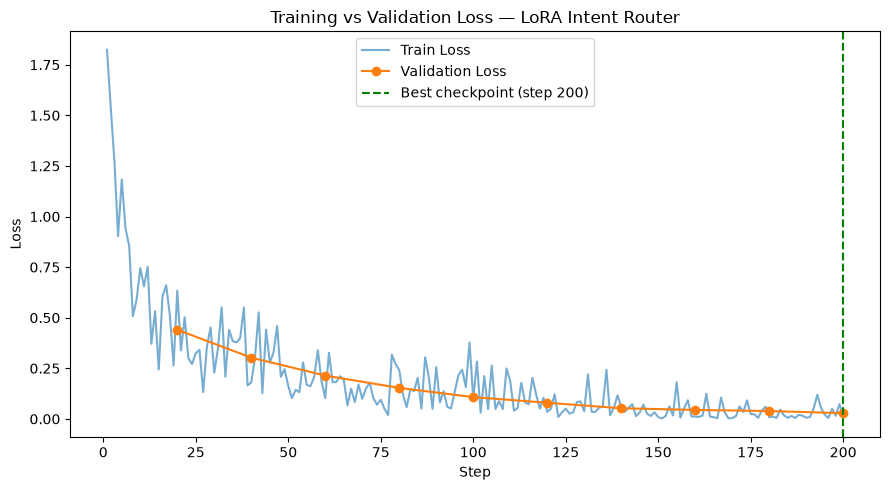

Lowest validation loss: 0.0284 at step 200
Validation loss was still improving when training stopped.


In [4]:
import matplotlib.pyplot as plt
import pandas as pd

train_df = pd.DataFrame(train_losses, columns=["step", "train_loss"])
val_df = pd.DataFrame(val_losses, columns=["step", "val_loss"])
best_step = val_df.loc[val_df["val_loss"].idxmin(), "step"]

plt.figure(figsize=(9, 5))
plt.plot(train_df["step"], train_df["train_loss"], label="Train Loss", alpha=0.6)
plt.plot(val_df["step"], val_df["val_loss"], label="Validation Loss", marker="o")
plt.axvline(best_step, color="green", linestyle="--", label=f"Best checkpoint (step {int(best_step)})")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss — LoRA Intent Router")
plt.legend()
plt.tight_layout()
plt.savefig("training_curves.png", dpi=100)
plt.show()

print(f"Lowest validation loss: {val_df['val_loss'].min():.4f} at step {int(best_step)}")
if val_df["val_loss"].iloc[-1] > val_df["val_loss"].min():
    print("Validation loss rose after its minimum — early stopping correctly preserves the BEST "
          "checkpoint rather than the final (potentially overfit) one.")
else:
    print("Validation loss was still improving when training stopped.")


#### **4.2.2 Save Training Outputs [2 marks]**
**The Task:** Save the best checkpoint (by validation loss), document the checkpoint/model-saving workflow, and export reproducibility information.

**Hints & Tips:**
* Save two checkpoints: `./intent_lora_best/` (lowest val loss) and `./intent_lora/` (final step).
* Export a `training_log.csv` with columns `step, train_loss, val_loss`.
* Record reproducibility info: model ID, LoRA config, learning rate, batch size, seed.

**Learner Inference:** Saving the BEST checkpoint (not the last) ensures your final model is the one that generalised best, not one that started overfitting.

In [5]:
import json

# Final checkpoint (last training step) — backup
peft_model.load_state_dict(final_state_dict)
peft_model.save_pretrained("./intent_lora")
print("Saved FINAL checkpoint (last step) to ./intent_lora")

# Best checkpoint (lowest validation loss) — used for inference in Notebook 7
peft_model.load_state_dict(best_state_dict)
peft_model.save_pretrained("./intent_lora_best")
tokenizer.save_pretrained("./intent_lora_best")
print("Saved BEST checkpoint (lowest val_loss) to ./intent_lora_best  <- used by Notebook 7")

train_log_df = pd.merge(train_df, val_df, on="step", how="outer").sort_values("step")
train_log_df.to_csv("training_log.csv", index=False)
print("\nSaved training_log.csv")

reproducibility_info = {
    "MODEL_ID": MODEL_ID,
    "lora_config": {"r": 16, "lora_alpha": 32, "lora_dropout": 0.05, "target_modules": ["q_proj", "v_proj"]},
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "max_steps": MAX_STEPS,
    "actual_steps": step,
    "val_every": VAL_EVERY,
    "patience": PATIENCE,
    "seed": SEED,
    "best_val_loss": best_val_loss,
    "best_step": int(best_step),
    "early_stopped": early_stopped,
    "device": DEVICE,
    "precision": "bfloat16 + gradient checkpointing (MPS training — bitsandbytes/QLoRA unavailable, see Project Proposal 1.4.3; switched from an initial fp32 attempt after fp32 caused system-wide swap thrashing on this 24GB machine)",
}
with open("training_reproducibility.json", "w") as f:
    json.dump(reproducibility_info, f, indent=2)

print("\nSaved training_reproducibility.json:")
print(json.dumps(reproducibility_info, indent=2))


Saved FINAL checkpoint (last step) to ./intent_lora


Saved BEST checkpoint (lowest val_loss) to ./intent_lora_best  <- used by Notebook 7

Saved training_log.csv

Saved training_reproducibility.json:
{
  "MODEL_ID": "Qwen/Qwen2.5-1.5B-Instruct",
  "lora_config": {
    "r": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
    "target_modules": [
      "q_proj",
      "v_proj"
    ]
  },
  "learning_rate": 0.0002,
  "batch_size": 2,
  "max_steps": 200,
  "actual_steps": 200,
  "val_every": 20,
  "patience": 3,
  "seed": 42,
  "best_val_loss": 0.02841290179795275,
  "best_step": 200,
  "early_stopped": false,
  "device": "mps",
  "precision": "bfloat16 + gradient checkpointing (MPS training \u2014 bitsandbytes/QLoRA unavailable, see Project Proposal 1.4.3; switched from an initial fp32 attempt after fp32 caused system-wide swap thrashing on this 24GB machine)"
}


---
## END-OF-NOTEBOOK CHECKLIST

> **IMPORTANT: Verify before proceeding to Notebook 7.**

- [ ] Tokenized train/valid loaded from disk (`set_format` re-applied)
- [ ] **4.1.1** LoRA configured targeting `q_proj`/`v_proj`
- [ ] **4.1.2** Optimizer + training params + dataloaders set
- [ ] **4.2.1** Training loop run with val monitoring + early stopping + loss curve
- [ ] **4.2.2** Best checkpoint saved + reproducibility info recorded
- [ ] **`./intent_lora_best/` saved** ← _CRITICAL for NB7_
- [ ] **`training_log.csv` + `training_curves.png` saved** ← _Evidence_

**If any item is unchecked, fix it before moving on.**